##  Import Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


## Load Dataset

In [2]:
# Load the dataset
data = load_breast_cancer()
# Separate features and labels
X = data.data
y = data.target
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (569, 30)
Labels shape: (569,)


## Put Data into a DataFrame

In [3]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
# Add target column
df["target"] = y
df.head()
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1]-1)

Number of samples: 569
Number of features: 30


## Visualization — Class Distribution

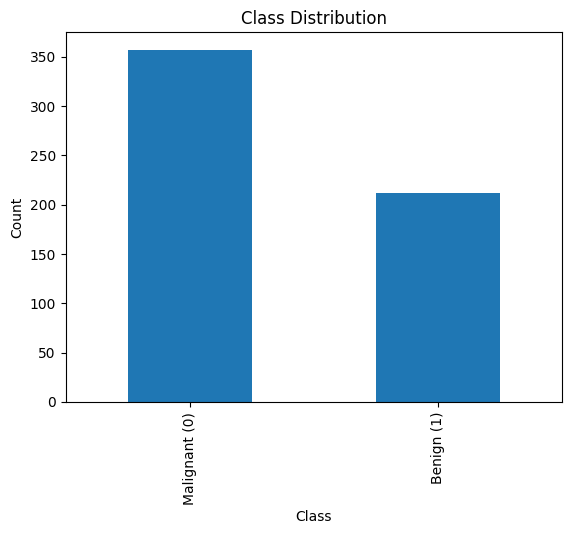

target
1    357
0    212
Name: count, dtype: int64


In [4]:
# Count classes
class_counts = df["target"].value_counts()

plt.figure()
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], ["Malignant (0)", "Benign (1)"])
plt.show()
print(class_counts)

## Check Null Values and Duplicates

In [5]:
# Null values
print("Null values in each column:")
print(df.isnull().sum())

# Duplicate rows
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

Null values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Number of duplicate rows: 0


## Feature Distribution

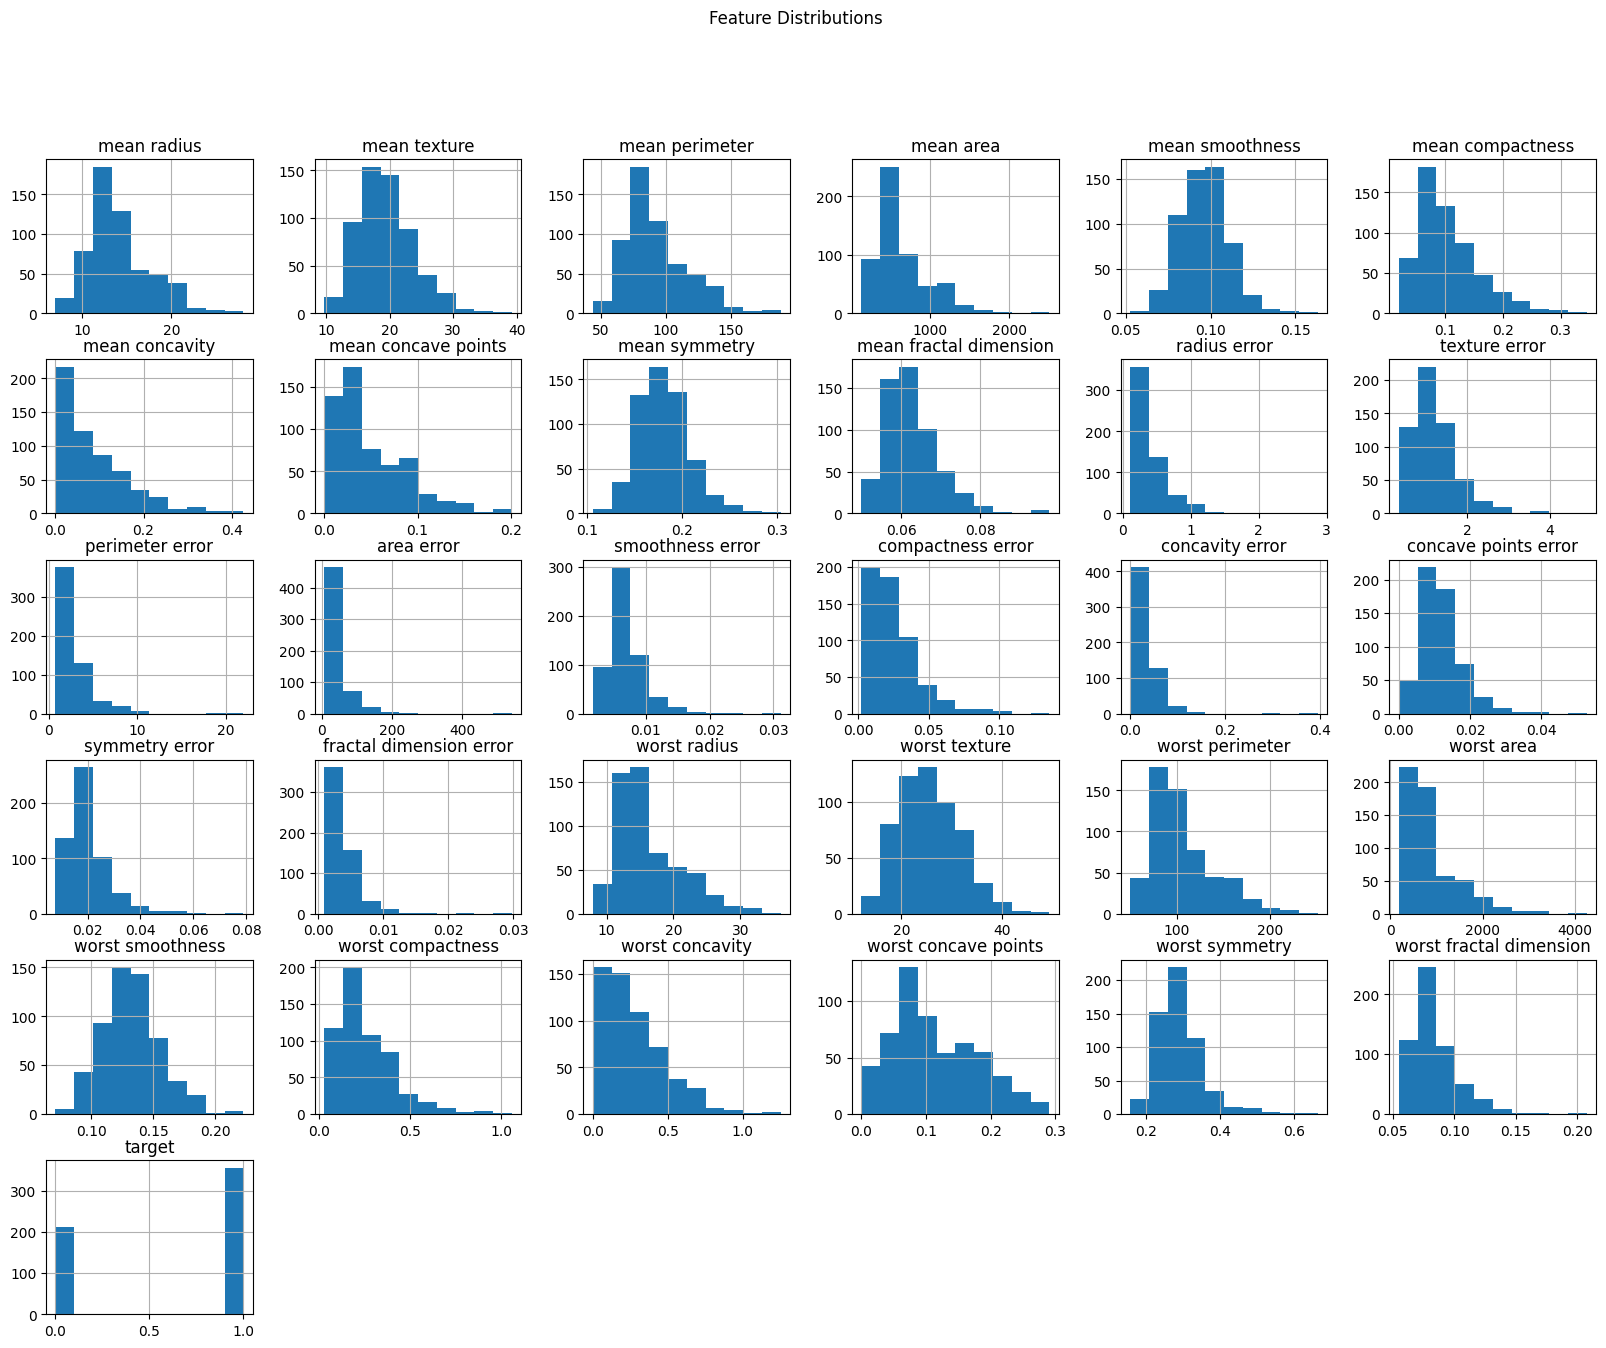

In [6]:
df.hist(figsize=(20,15))
plt.suptitle("Feature Distributions")
plt.show()

## Outlier Detection Using IQR

In [7]:
# Separate features (without target)
features = df.drop("target", axis=1)

Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
# Outlier condition
outliers = ((features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR)))
# Count total outliers
print("Total outliers:", outliers.sum().sum())

Total outliers: 608


## Handle Outliers — Winsorization (Capping)

In [8]:
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply capping
features_capped = features.clip(lower=lower_bound, upper=upper_bound, axis=1)
# Replace in dataframe
df_capped = features_capped.copy()
df_capped["target"] = df["target"]

## Recheck Outliers After Capping

In [9]:
features = df_capped.drop("target", axis=1)

Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
outliers_after = ((features < (Q1 - 1.5 * IQR)) | (features > (Q3 + 1.5 * IQR)))
print("Remaining outliers:", outliers_after.sum().sum())

Remaining outliers: 0


## Visualization After Capping

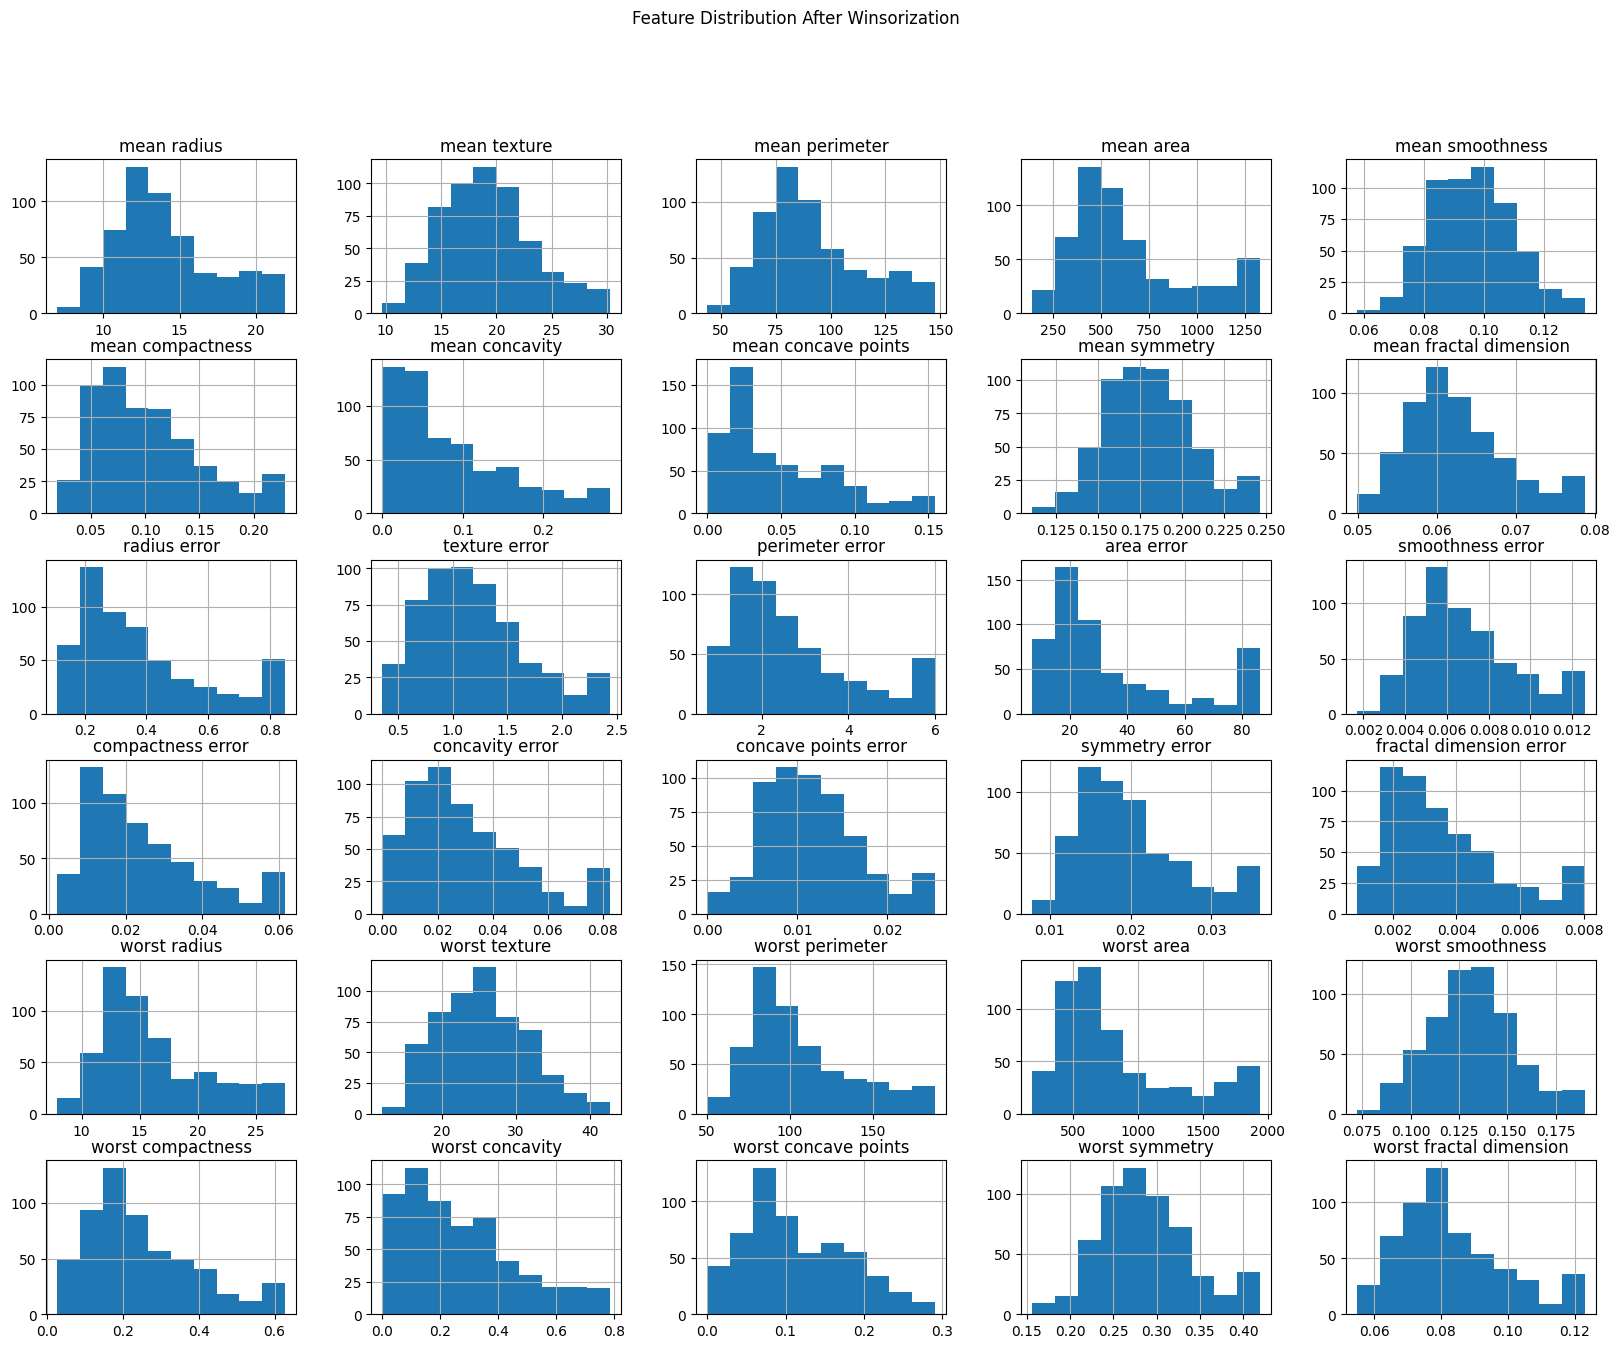

In [10]:
df_capped.drop("target", axis=1).hist(figsize=(20,15))
plt.suptitle("Feature Distribution After Winsorization")
plt.show()

## Splitting the data

In [11]:
X = df_capped.drop("target", axis=1)
y = df_capped["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (455, 30)
Test shape: (114, 30)


## Standard Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train shape:", X_train_scaled.shape)

Train shape: (455, 30)


## Convert Data to PyTorch Tensors

In [13]:
import torch

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

## Reshape Labels Properly

In [14]:
y_train_tensor = y_train_tensor.view(-1,1)
y_test_tensor = y_test_tensor.view(-1,1)

## Verify Data Types and Shapes

In [15]:
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

print("\nData types:")
print(X_train_tensor.dtype)
print(y_train_tensor.dtype)

X_train_tensor shape: torch.Size([455, 30])
y_train_tensor shape: torch.Size([455, 1])
X_test_tensor shape: torch.Size([114, 30])
y_test_tensor shape: torch.Size([114, 1])

Data types:
torch.float32
torch.float32


## Implement Logistic Regression Model (Neural Network)

In [16]:

class LogisticRegressionModel(nn.Module):

    def __init__(self, input_size):
        super(LogisticRegressionModel, self).__init__()

        self.linear = nn.Linear(input_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

## Define Loss Function and optimizer

In [17]:
input_size = X_train_tensor.shape[1]

model = LogisticRegressionModel(input_size)

print(model)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

LogisticRegressionModel(
  (linear): Linear(in_features=30, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Train the Model (Forward → Loss → Backpropagation)

In [18]:
num_epochs = 100
loss_history = []

for epoch in range(num_epochs):

    # Forward pass
    outputs = model(X_train_tensor)
    # Loss calculation
    loss = criterion(outputs, y_train_tensor)
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    # Update weights
    optimizer.step()
    # Save loss
    loss_history.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.4487
Epoch [20/100], Loss: 0.4100
Epoch [30/100], Loss: 0.3780
Epoch [40/100], Loss: 0.3517
Epoch [50/100], Loss: 0.3298
Epoch [60/100], Loss: 0.3113
Epoch [70/100], Loss: 0.2955
Epoch [80/100], Loss: 0.2818
Epoch [90/100], Loss: 0.2697
Epoch [100/100], Loss: 0.2589


## Visualize Loss Across Epochs

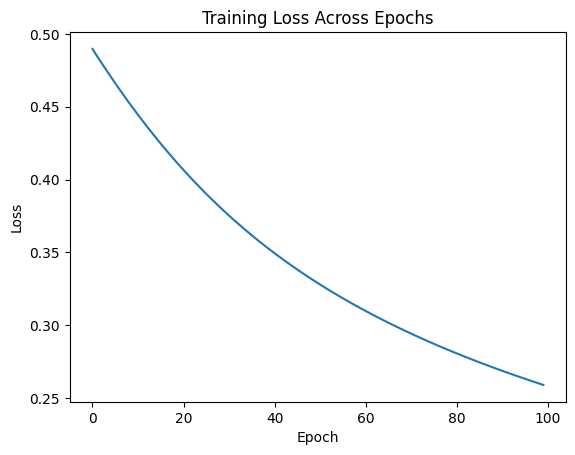

In [19]:
plt.figure()

plt.plot(loss_history)

plt.title("Training Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

## Evaluate the Model on Test Data

In [20]:
# Disable gradient calculation for evaluation
with torch.no_grad():
    
    test_outputs = model(X_test_tensor)
    # Convert probabilities to class labels
    predicted = (test_outputs >= 0.5).float()

# Convert tensors to numpy
y_true = y_test_tensor.numpy()
y_pred = predicted.numpy()

## Compute Accuracy, Precision, Recall, F1-score

In [21]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Model Performance:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Model Performance:
Accuracy : 0.9736842105263158
Precision: 0.9857142857142858
Recall   : 0.971830985915493
F1-score : 0.9787234042553191


## Display Confusion Matrix

In [22]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[42  1]
 [ 2 69]]


## Visualize the Confusion Matrix

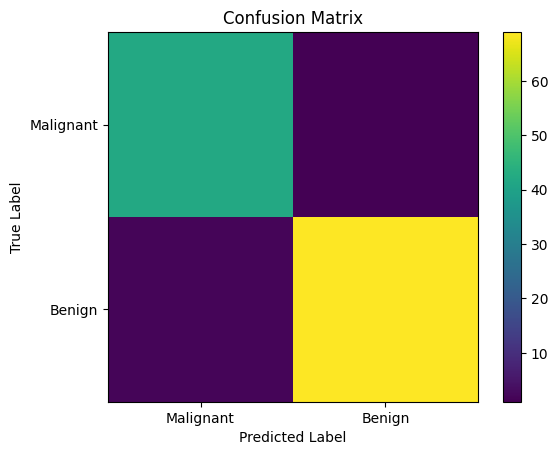

In [23]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.xticks([0,1], ["Malignant","Benign"])
plt.yticks([0,1], ["Malignant","Benign"])
plt.show()

### Discussion: Role of Sigmoid Activation

* **Role of the Sigmoid Function:** The sigmoid activation function converts the output of the linear layer into a probability value between 0 and 1.
* **Mathematical Formula:**

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$


* **Interpretation:** This allows the model to interpret the output as the probability $P$ that a tumor is malignant.
* **Classification Logic:**
* **Class 1 (Benign):** If $P \geq 0.5$
* **Class 0 (Malignant):** If $P < 0.5$



---

### Conclusion

The sigmoid function enables the neural network to perform binary classification by mapping raw model outputs into interpretable probabilities.

### Model Performance Analysis

* **High Accuracy:** The logistic regression neural network achieved high accuracy on the Breast Cancer dataset, indicating the model successfully learned the relationship between input features and tumor classification.
* **Precision and Recall:** Both values are high, suggesting the model effectively identifies both malignant and benign cases.
* **Confusion Matrix:** The results show only a small number of samples were misclassified, confirming the model's reliability.

---

### Conclusion

* **Model Suitability:** This result is expected because the Breast Cancer dataset is relatively well-structured and linearly separable.
* **Efficiency:** Logistic regression is sufficient to achieve strong performance on this specific task without the added complexity of a deep neural network.

## Implement the Shallow Neural Network

In [24]:
class ShallowNeuralNetwork(nn.Module):

    def __init__(self, input_size):
        super(ShallowNeuralNetwork, self).__init__()

        # First hidden layer
        self.hidden1 = nn.Linear(input_size, 16)
        self.relu1 = nn.ReLU()
        # Second hidden layer
        self.hidden2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        # Output layer
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

## Define Loss and Optimizer

In [25]:
input_size = X_train_tensor.shape[1]
shallow_model = ShallowNeuralNetwork(input_size)
print(shallow_model)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(shallow_model.parameters(), lr=0.001)

ShallowNeuralNetwork(
  (hidden1): Linear(in_features=30, out_features=16, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Train the Shallow Neural Network

In [26]:
num_epochs = 100
shallow_loss_history = []

for epoch in range(num_epochs):
    outputs = shallow_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    shallow_loss_history.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.6493
Epoch [20/100], Loss: 0.6191
Epoch [30/100], Loss: 0.5840
Epoch [40/100], Loss: 0.5410
Epoch [50/100], Loss: 0.4897
Epoch [60/100], Loss: 0.4313
Epoch [70/100], Loss: 0.3673
Epoch [80/100], Loss: 0.3029
Epoch [90/100], Loss: 0.2465
Epoch [100/100], Loss: 0.2029


## Visualize Loss

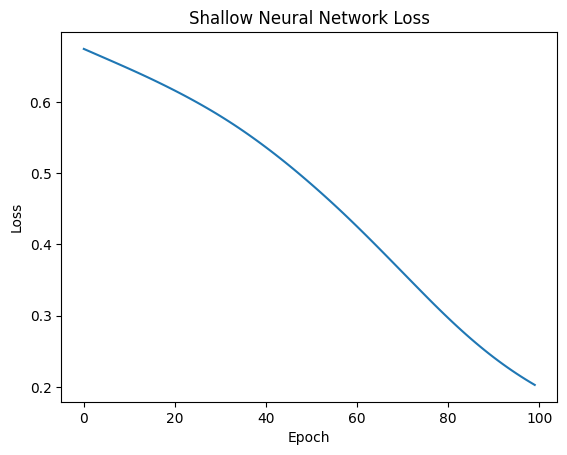

In [27]:
plt.figure()
plt.plot(shallow_loss_history)
plt.title("Shallow Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Evaluate the Shallow Model

In [28]:
with torch.no_grad():

    test_outputs = shallow_model(X_test_tensor)
    predicted = (test_outputs >= 0.5).float()

y_pred_shallow = predicted.numpy()

## Compute Metrics

In [29]:
accuracy_shallow = accuracy_score(y_true, y_pred_shallow)
precision_shallow = precision_score(y_true, y_pred_shallow)
recall_shallow = recall_score(y_true, y_pred_shallow)
f1_shallow = f1_score(y_true, y_pred_shallow)

print("Shallow Neural Network Performance:")
print("Accuracy :", accuracy_shallow)
print("Precision:", precision_shallow)
print("Recall   :", recall_shallow)
print("F1-score :", f1_shallow)

Shallow Neural Network Performance:
Accuracy : 0.9824561403508771
Precision: 0.9859154929577465
Recall   : 0.9859154929577465
F1-score : 0.9859154929577465


## Compare Both Models

In [30]:
print("Logistic Regression Accuracy:", accuracy)
print("Shallow Neural Network Accuracy:", accuracy_shallow)

Logistic Regression Accuracy: 0.9736842105263158
Shallow Neural Network Accuracy: 0.9824561403508771


### Comparison Between Logistic Regression and Shallow Neural Network

* **Experimental Setup:** A shallow neural network with one hidden layer and **ReLU** activation was implemented to compare against the standard logistic regression model.
* **Non-linearity:** The shallow network introduces non-linear decision boundaries via the **Rectified Linear Unit (ReLU)** function:

$$f(x) = \max(0, x)$$



This allows the model to capture more complex relationships between features than a linear model.
* **Dataset Characteristics:** Because the Breast Cancer dataset is relatively simple and mostly **linearly separable**, logistic regression already achieves high accuracy.
* **Performance Comparison:** The shallow neural network may only provide marginal improvements or similar performance levels due to the nature of the data.
* **Model Complexity:** Deeper or more complex models are not always necessary when a dataset can be modeled effectively with simpler algorithms.
